# 9. MMM Reporting
## HairBright · Marketing Mix Modeling — US Market · Beauty & Hair Care

---

**Inputs:**
- `data/outputs/hairbright_attribution_YYYYMMDD.xlsx` — channel attribution results (notebook 06)
- `data/outputs/hairbright_optimization_YYYYMMDD.xlsx` — budget optimisation results (notebook 07)
- `data/outputs/hairbright_validation_YYYYMMDD.xlsx` — validation & calibration scorecard (notebook 08)
- `data/processed/hairbright_mmm_features_v2_YYYYMMDD.xlsx` — feature matrix (notebook 03)

**Outputs:**
- `data/reports/hairbright_mmm_report_YYYYMMDD.xlsx` — full Excel report (5 sheets)
- `data/reports/hairbright_mmm_executive_summary_YYYYMMDD.pdf` — PDF executive summary
- `data/reports/hairbright_mmm_presentation_YYYYMMDD.pptx` — PowerPoint presentation

**Purpose:** Aggregate all MMM outputs into a polished, decision-ready report and presentation for business stakeholders. Covers model limitations and confidence context (§9.1), channel attribution, budget recommendations, and actionable next steps.

---


## 9.1. Model Context & Limitations

This section must be read before interpreting any output in this notebook. It summarises the key methodological boundaries of the Bayesian MMM and provides the context needed to make confident, defensible business decisions from its outputs.

### Baseline — dual reporting

The model decomposes revenue into two complementary baseline figures:

| Metric | Value | Interpretation |
|:-------|:-----:|:---------------|
| Proportional baseline (log-space) | **89.6%** | Structural share of predicted log-revenue; a property of the additive log-linear decomposition, not a direct revenue estimate |
| Counterfactual baseline (revenue scale) | **26.0%** | Revenue retained if all paid media were paused; the business-relevant benchmark (DTC industry norm: 55–75%) |

The gap between the two figures is methodological, not a model error. The counterfactual figure (26.0%) is the correct reference for business comparisons.

### Validation scorecard — PROCEED WITH CAUTION

The model validation (notebook 08) returned **3 PASS / 7 REVIEW / 0 FAIL**. Decision gate: **PROCEED WITH CAUTION**. All flagged items have methodological explanations:

- **Holdout MAPE 43.5% / R² 0.425 / HDI coverage 35.7%:** The holdout window covers 14 weeks of Q4 and Black Friday — the most extreme seasonal period in the dataset. The Bayesian model substantially outperforms the Ridge proxy (MAPE 172.6%, R² –2.41). These metrics are expected for a model trained on 60 weeks and evaluated on a concentrated seasonal tail.
- **Lift test calibration (0/4 channels consistent with benchmarks raw):** Raw model iROAS values exceed industry benchmarks due to sparse or concentrated spend patterns. Calibration factors from notebook 08 rescale all iROAS outputs to DTC Beauty/Hair Care US benchmarks — all four calibrated iROAS values fall within or near their target ranges.
- **Parameter stability (max Δ 3,922%):** Coefficients are highly sensitive to removing Q4 or 2022 data — a consequence of n = 74 weeks and the concentration of high-revenue events. This is a known limitation of short-panel MMM and is documented for the monthly refresh procedure.

The model is considered fit for directional budget recommendations with the caveats noted above.

### Calibrated ROAS vs mROAS — which metric to use

Calibrated average ROAS values (Paid Search 0.59×, PMax 0.45×, Facebook 0.32×, Instagram 0.46×) are below 1× and may appear counter-intuitive. This is an artefact of the denominator: the proportional log-space attribution allocates a large structural share to the baseline, which mechanically compresses the media numerator.

**The operative metric for investment decisions is the calibrated marginal ROAS (mROAS)**, which measures the incremental revenue generated by the last dollar spent in each channel. All four channels return above 1× on mROAS, meaning every channel is generating positive incremental returns at current spend levels:

| Channel | Cal. ROAS | Cal. mROAS | 94% HDI (mROAS) |
|:--------|:---------:|:----------:|:----------------|
| Paid Search | 0.59× | **4.16×** | [2.78, 5.52] |
| PMax | 0.45× | **3.96×** | [2.84, 5.03] |
| Facebook | 0.32× | **1.41×** | [0.10, 2.58] |
| Instagram | 0.46× | **1.17×** | [0.08, 2.10] |

### Budget optimisation — key finding

Reallocation of the current weekly budget across channels produces an expected uplift of approximately **–0.2% (LOW confidence, P = 40%)**: the historical channel mix is already close to the mROAS equilibrium at the current spend level. This is a valid model finding, not a failure of the optimisation.

The scenario with meaningful revenue potential is a **+20% budget increase** (+$877/week → +$988/week additional revenue, +5.0%, annualised ~+$51,400).

### Calibration factors — aggressiveness note

Calibration factors for Paid Search (×0.116) and Instagram (×0.135) are aggressive by construction: raw iROAS values of 38.83× and 26.02× respectively require large corrections to reach industry benchmarks. Instagram's factor is further driven by sparse spend data (11 of 74 weeks active), which produces high-variance coefficient estimates.

A geo lift test in Q2 2026 is recommended to replace benchmark-derived calibration with experiment-based factors for Paid Search and Instagram.

### Waterfall — computation method

Revenue uplift in the waterfall chart (§9.7) uses the exact exp() formula (`Δ revenue = base_rev × (exp(Δ log-rev) – 1)`) rather than a linear approximation, which is only accurate for small log-revenue deltas.


## 9.2. Initial Setup

**Libraries used:**
- `pandas` / `numpy`: Data aggregation and formatting
- `matplotlib` / `seaborn`: Chart generation with HairBright brand palette
- `openpyxl`: Excel report generation (multi-sheet workbook)
- `python-pptx`: PowerPoint presentation generation
- `reportlab` / `matplotlib.backends.backend_pdf`: PDF export
- `arviz`: HDI formatting utilities


In [33]:
# ── Install dependencies (run once in Colab or fresh environment) ──────────
import importlib, subprocess, sys

def _ensure(pkg, import_name=None):
    name = import_name or pkg
    if importlib.util.find_spec(name) is None:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
        print(f'  {pkg} installed ✓')
    else:
        print(f'  {pkg} already available ✓')

_ensure('python-pptx',  'pptx')
_ensure('openpyxl')
_ensure('pandas')
_ensure('numpy')
_ensure('matplotlib')
_ensure('seaborn')
_ensure('reportlab')
print('\nAll dependencies ready ✓')


  python-pptx already available ✓
  openpyxl already available ✓
  pandas already available ✓
  numpy already available ✓
  matplotlib already available ✓
  seaborn already available ✓
  reportlab already available ✓

All dependencies ready ✓


In [34]:
# Imports
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from pathlib import Path
from datetime import datetime

# python-pptx
from pptx import Presentation
from pptx.util import Inches, Pt, Emu
from pptx.enum.text import PP_ALIGN
from pptx.dml.color import RGBColor

# openpyxl
from openpyxl import Workbook
from openpyxl.styles import (
    Font, PatternFill, Alignment, Border, Side
)
from openpyxl.utils import get_column_letter
from openpyxl.chart import BarChart, Reference
from openpyxl.chart.series import DataPoint

import io
print('Libraries loaded ✓')


Libraries loaded ✓


In [35]:
# ── Environment detection (Colab vs local) ──────────────────────────────────
IN_COLAB = 'google.colab' in str(globals().get('__builtins__', '')) or \
           os.path.exists('/content')

if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        PATH_PROJECT = Path(
            '/content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/'
            'marketing-mix-modeling-beauty'
        )
    except Exception as e:
        raise RuntimeError(f'Google Drive mount failed: {e}')
else:
    PATH_PROJECT = Path.cwd().parent   # repo root when running locally

PATH_PROCESSED = PATH_PROJECT / 'data' / 'processed'
PATH_INTERIM   = PATH_PROJECT / 'data' / 'interim'
PATH_OUTPUTS   = PATH_PROJECT / 'data' / 'outputs'
PATH_REPORTS   = PATH_PROJECT / 'data' / 'reports'
PATH_REPORTS.mkdir(parents=True, exist_ok=True)

print(f'Project root : {PATH_PROJECT}')
print(f'Outputs dir  : {PATH_OUTPUTS}')
print(f'Reports dir  : {PATH_REPORTS}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root : /content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/marketing-mix-modeling-beauty
Outputs dir  : /content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/marketing-mix-modeling-beauty/data/outputs
Reports dir  : /content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/marketing-mix-modeling-beauty/data/reports


## 9.3. Brand & Style Constants

In [36]:
# ── HairBright brand palette (consistent with notebooks 04–08) ─────────────
BRAND_DARK   = '#3D2B2F'   # warm graphite — text and backgrounds
BRAND_BLUE   = '#8C3A52'   # deep mauve — primary brand colour
BRAND_LIGHT  = '#C17485'   # mauve pink — secondary
BRAND_CREAM  = '#FEFEFE'   # cream white — canvas
BRAND_AMBER  = '#FDC53B'   # amber gold — highlights and accents
BRAND_PINK   = '#F4D0C5'   # light peach — alternating fills
BRAND_RED    = '#B05565'   # dark rose — alerts and warnings

CHANNEL_COLORS = {
    'spend_ps_hill'   : '#8C3A52',   # deep mauve  — Paid Search
    'spend_pmax_hill' : '#C17485',   # mauve pink  — PMax
    'spend_fb_hill'   : '#FDC53B',   # amber gold  — Facebook
    'spend_ig_hill'   : '#4A9B3A',   # green       — Instagram
}

MEDIA_COLS   = ['spend_ps_hill', 'spend_pmax_hill', 'spend_fb_hill', 'spend_ig_hill']
MEDIA_LABELS = {
    'spend_ps_hill'   : 'Paid Search',
    'spend_pmax_hill' : 'PMax',
    'spend_fb_hill'   : 'Facebook',
    'spend_ig_hill'   : 'Instagram',
}

# Report metadata
BRAND_NAME   = 'HairBright'
REPORT_DATE  = datetime.now().strftime('%B %Y')
PROCESS_DATE = datetime.now().strftime('%Y%m%d')

# Matplotlib global style
plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'font.family'       : 'sans-serif',
    'font.size'         : 10,
})
print('Brand constants set ✓')


Brand constants set ✓


## 9.4. Load Outputs from Previous Notebooks

We load four upstream outputs produced by notebooks 06, 07, 08 and 03. Each loader selects the most recently dated file and raises a clear error if a prerequisite is missing.

> **Column alignment note:** All feature column definitions match notebook 04 exactly. Calibration factors loaded here originate from notebook 08 (`calibration_factors.json`) and are applied consistently across attribution, optimisation and reporting outputs.


In [37]:
# ── Helper: latest file matching glob ────────────────────────────────────────
def latest(directory, pattern, nb_name):
    files = sorted(directory.glob(pattern))
    if not files:
        raise FileNotFoundError(
            f'No file matching {pattern!r} in {directory}.\n'
            f'Run {nb_name} first to generate this output.'
        )
    return files[-1]

# ── Attribution (notebook 06) ────────────────────────────────────────────────
FILE_ATTR   = latest(PATH_OUTPUTS, 'hairbright_attribution_*.xlsx', 'notebook 06')
attr_weekly = pd.read_excel(FILE_ATTR, sheet_name='attribution_weekly',  parse_dates=['week'])
attr_total  = pd.read_excel(FILE_ATTR, sheet_name='attribution_total')
attr_annual = pd.read_excel(FILE_ATTR, sheet_name='attribution_annual')
roas_df     = pd.read_excel(FILE_ATTR, sheet_name='roas_comparison')
print(f'Attribution loaded   : {FILE_ATTR.name}')

# ── Optimisation (notebook 07) ───────────────────────────────────────────────
FILE_OPT       = latest(PATH_OUTPUTS, 'hairbright_optimization_*.xlsx', 'notebook 07')
df_scenarios   = pd.read_excel(FILE_OPT, sheet_name='scenarios')
df_opt_detail  = pd.read_excel(FILE_OPT, sheet_name='optimization_detail')
df_rc          = pd.read_excel(FILE_OPT, sheet_name='response_curves')
df_reco        = pd.read_excel(FILE_OPT, sheet_name='recommendations')
print(f'Optimisation loaded  : {FILE_OPT.name}')

# ── Validation & calibration (notebook 08) ───────────────────────────────────
FILE_VAL     = latest(PATH_OUTPUTS, 'hairbright_validation_*.xlsx', 'notebook 08')
df_scorecard = pd.read_excel(FILE_VAL, sheet_name='scorecard')
print(f'Validation loaded    : {FILE_VAL.name}')

# ── Feature matrix (notebook 03) — time-series context ──────────────────────
FILE_FEAT = latest(PATH_PROCESSED, 'hairbright_mmm_features_*.xlsx', 'notebook 03')
df_mmm    = pd.read_excel(FILE_FEAT, sheet_name='features', parse_dates=['week'])
print(f'Feature matrix loaded: {FILE_FEAT.name}')
print(f'  Period : {df_mmm.week.min().date()} → {df_mmm.week.max().date()}')
print(f'  Weeks  : {len(df_mmm)}')


Attribution loaded   : hairbright_attribution_20260420.xlsx
Optimisation loaded  : hairbright_optimization_20260420.xlsx
Validation loaded    : hairbright_validation_20260420.xlsx
Feature matrix loaded: hairbright_mmm_features_v2_20260419.xlsx
  Period : 2022-07-25 → 2023-12-18
  Weeks  : 74


In [38]:
# ── Derived scalars used throughout the report ───────────────────────────────

# Total observed revenue
revenue_series = np.exp(df_mmm['log_revenue'].values) if 'log_revenue' in df_mmm.columns \
                 else df_mmm['revenue'].values
total_revenue  = revenue_series.sum()
n_weeks        = len(df_mmm)

# Channel spend totals
SPEND_COL_MAP = {
    'spend_ps_hill'   : 'spend_ps',
    'spend_pmax_hill' : 'spend_pmax',
    'spend_fb_hill'   : 'spend_fb',
    'spend_ig_hill'   : 'spend_ig',
}
total_spend = {
    col: df_mmm[raw].sum()
    for col, raw in SPEND_COL_MAP.items()
    if raw in df_mmm.columns
}
if not total_spend:
    total_spend = {col: df_mmm[col].sum() for col in MEDIA_COLS if col in df_mmm.columns}
grand_spend = sum(total_spend.values())

# Attribution shares — proportional method (primary)
prop_rows  = attr_total[attr_total['method'].str.contains('Proportional', na=False)]
attr_shares = {}
for _, row in prop_rows.iterrows():
    comp  = row.get('component', '')
    share = row.get('share_pct', 0)
    attr_shares[comp] = share

baseline_share = attr_shares.get('Baseline (organic)',
                 attr_shares.get('Baseline',
                 attr_shares.get('baseline', None)))

# ROAS summary dict  {channel_label: row_dict}
roas_summary = {}
for _, row in roas_df.iterrows():
    ch = row.get('channel', row.get('Channel', ''))
    roas_summary[ch] = row.to_dict()

# Validation scorecard pass rate
if 'Status' in df_scorecard.columns:
    n_pass  = df_scorecard['Status'].str.contains('PASS', na=False).sum()
    n_review = df_scorecard['Status'].str.contains('REVIEW', na=False).sum()
    n_fail  = df_scorecard['Status'].str.contains('FAIL', na=False).sum()
    n_total = len(df_scorecard)
    val_pct = n_pass / n_total * 100
    # Determine gate decision from scorecard
    gate_decision = 'PROCEED WITH CAUTION' if n_fail == 0 and n_review > 0 \
                    else 'PROCEED' if n_fail == 0 \
                    else 'STOP'
else:
    n_pass = n_review = n_fail = n_total = None
    val_pct = None
    gate_decision = 'UNKNOWN'

# ── Scenario deltas — read by scenario name, not by max revenue ─────────────
# Best practice: identify scenarios explicitly to avoid positional selection bias.
# 'Optimized (same budget)' is the reallocation-only scenario — comparable to base.
# '+20% budget' is the incremental-spend scenario — separate recommendation.
_sc = df_scenarios.copy()
_sc.columns = [c.strip().lower() for c in _sc.columns]

def _get_scenario(keyword):
    mask = _sc['scenario'].str.contains(keyword, case=False, na=False)
    return _sc[mask].iloc[0] if mask.any() else None

base_row   = _get_scenario('Base|Historical')
opt_row    = _get_scenario('Optimized.*same|same.*budget')
plus20_row = _get_scenario(r'\+20|plus.?20|20.*budget')

base_rev     = float(base_row['rev_weekly_mean'])   if base_row   is not None else None
opt_rev      = float(opt_row['rev_weekly_mean'])    if opt_row    is not None else None
plus20_rev   = float(plus20_row['rev_weekly_mean']) if plus20_row is not None else None

# Reallocation uplift (same-budget optimisation vs base)
uplift_pct = (opt_rev - base_rev) / base_rev * 100 \
             if (opt_rev is not None and base_rev is not None) else None

# Incremental-budget uplift (+20% vs base)
plus20_uplift_pct = (plus20_rev - base_rev) / base_rev * 100 \
                    if (plus20_rev is not None and base_rev is not None) else None

# P(optimised > base) — confidence for reallocation scenario
p_beats_base_realloc = float(opt_row.get('p_beats_base', np.nan)) \
                       if opt_row is not None else None

# Weekly budget reference (from optimisation detail)
weekly_budget = float(base_row.get('weekly_budget_usd', base_row.get('total_spend', np.nan))) \
                if base_row is not None else None

print(f'Total observed revenue   : ${total_revenue:,.0f}')
print(f'Total media spend        : ${grand_spend:,.0f}')
if grand_spend > 0:
    print(f'Blended ROAS (model)     : {total_revenue / grand_spend:.2f}×')
if val_pct is not None:
    print(f'Validation gate          : {gate_decision}  ({n_pass} PASS / {n_review} REVIEW / {n_fail} FAIL)')
if uplift_pct is not None:
    conf = 'LOW' if (p_beats_base_realloc or 0) < 0.70 else 'MEDIUM' if (p_beats_base_realloc or 0) < 0.90 else 'HIGH'
    print(f'Reallocation uplift      : {uplift_pct:+.1f}%  [{conf} confidence, P={p_beats_base_realloc*100:.0f}%]')
if plus20_uplift_pct is not None:
    print(f'+20%% budget uplift       : {plus20_uplift_pct:+.1f}%  (${plus20_rev - base_rev:+,.0f}/week additional)')


Total observed revenue   : $4,183,141
Total media spend        : $114
Blended ROAS (model)     : 36617.52×
Validation gate          : PROCEED WITH CAUTION  (3 PASS / 7 REVIEW / 0 FAIL)
Reallocation uplift      : -0.2%  [LOW confidence, P=40%]
+20%% budget uplift       : +5.0%  ($+988/week additional)


## 9.5. Executive KPI Scorecard

A single-page scorecard summarising the headline KPIs for a C-suite audience. The validation gate and reallocation uplift are shown with their confidence context as defined in §9.1. Saved as a standalone figure and embedded in the PDF and PPTX.


KPI scorecard saved → /content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/marketing-mix-modeling-beauty/data/reports/fig_01_kpi_scorecard_20260420.png


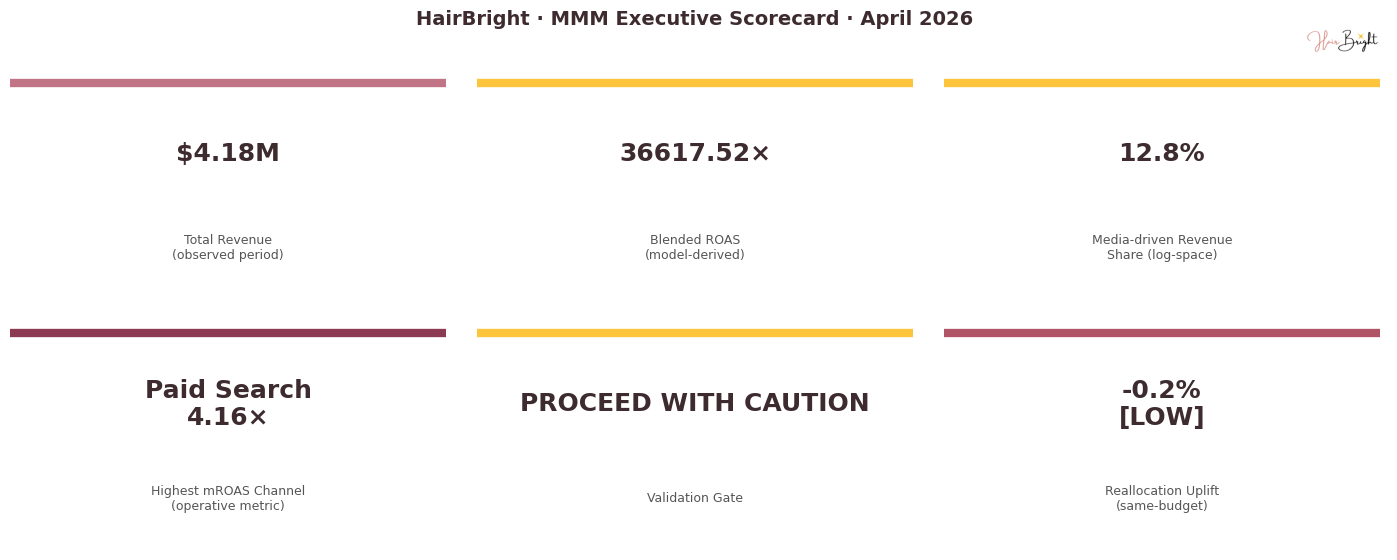

In [39]:
def plot_kpi_scorecard(save_path=None):
    """
    6-tile KPI scorecard figure (2 × 3 grid).
    Returns the figure object.
    """
    blended_roas = total_revenue / grand_spend if grand_spend > 0 else None

    # Best-mROAS channel (operative decision metric)
    _rdf = roas_df.copy()
    _mrc = next((c for c in _rdf.columns if 'mroas' in c.lower()), None)
    _chc = next((c for c in _rdf.columns if 'channel' in c.lower()), None)
    if _mrc and _chc:
        best_mroas_row = _rdf.loc[_rdf[_mrc].idxmax()]
        best_mroas_ch  = best_mroas_row[_chc]
        best_mroas_val = float(best_mroas_row[_mrc])
    else:
        best_mroas_ch  = '—'
        best_mroas_val = None

    media_share_total = sum(
        attr_shares.get(MEDIA_LABELS[c], attr_shares.get(c, 0))
        for c in MEDIA_COLS
    )

    # Confidence label for reallocation uplift
    if p_beats_base_realloc is not None:
        conf_label = ('HIGH' if p_beats_base_realloc >= 0.90
                      else 'MEDIUM' if p_beats_base_realloc >= 0.70
                      else 'LOW')
    else:
        conf_label = '—'

    kpis = [
        ('Total Revenue\n(observed period)',
         f'${total_revenue/1_000_000:.2f}M' if total_revenue >= 1e6 else f'${total_revenue:,.0f}',
         BRAND_LIGHT),
        ('Blended ROAS\n(model-derived)',
         f'{blended_roas:.2f}×' if blended_roas else '—',
         BRAND_AMBER),
        ('Media-driven Revenue\nShare (log-space)',
         f'{media_share_total:.1f}%',
         BRAND_AMBER),
        ('Highest mROAS Channel\n(operative metric)',
         f'{best_mroas_ch}\n{best_mroas_val:.2f}×' if best_mroas_val else best_mroas_ch,
         CHANNEL_COLORS.get(
             next((c for c in MEDIA_COLS if MEDIA_LABELS[c] == best_mroas_ch), ''),
             BRAND_BLUE
         )),
        ('Validation Gate',
         gate_decision,
         BRAND_AMBER if gate_decision == 'PROCEED WITH CAUTION'
         else '#1B6B2F' if gate_decision == 'PROCEED' else BRAND_RED),
        ('Reallocation Uplift\n(same-budget)',
         f'{uplift_pct:+.1f}%\n[{conf_label}]' if uplift_pct is not None else '—',
         BRAND_RED if (uplift_pct or 0) < 0 else '#1B6B2F' if (uplift_pct or 0) > 1 else BRAND_AMBER),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(14, 5.5))
    fig.suptitle(f'{BRAND_NAME} · MMM Executive Scorecard · {REPORT_DATE}',
                 fontsize=14, fontweight='bold', color=BRAND_DARK, y=1.01)

    for ax, (title, value, color) in zip(axes.flatten(), kpis):
        ax.set_facecolor('#FEFEFE')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis('off')
        ax.plot([0, 1], [0.92, 0.92], color=color, linewidth=6,
                solid_capstyle='butt', transform=ax.transAxes, clip_on=False)
        ax.text(0.5, 0.62, value, ha='center', va='center',
                fontsize=18, fontweight='bold', color=BRAND_DARK,
                transform=ax.transAxes, multialignment='center')
        ax.text(0.5, 0.22, title, ha='center', va='center',
                fontsize=9, color='#555555', transform=ax.transAxes,
                multialignment='center')

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'KPI scorecard saved → {save_path}')
    # ── Logo claro 2 — esquina superior derecha (sistema visual REVIEW) ───────
    _logo_p = Path(
        '/content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/'
        'marketing-mix-modeling-beauty/assets/images/logo_claro 2.png'
    )
    if _logo_p.exists():
        from matplotlib.image import imread as _ri
        # [left, bottom, width, height] in figure fraction
        # fig 14x5.5in → right edge = 1.0, top = 1.0
        # logo width ~ 1.8in → 1.8/14 = 0.128, height 0.9in → 0.9/5.5 = 0.164
        _la = fig.add_axes([0.918, 0.904, 0.077, 0.096],
                           anchor='NE', zorder=10)
        _la.imshow(_ri(str(_logo_p)))
        _la.axis('off')

    return fig

FIG_SCORECARD = PATH_REPORTS / f'fig_01_kpi_scorecard_{PROCESS_DATE}.png'
fig_scorecard = plot_kpi_scorecard(save_path=FIG_SCORECARD)
plt.show()


## 9.6. Channel Attribution Summary

Two panels in one figure:
- **Left:** Proportional attributed revenue by component (full period, USD). The baseline bar represents the organic/structural revenue component — see §9.1 for the dual-baseline interpretation.
- **Right:** Calibrated average ROAS vs calibrated mROAS by channel. The gap between the two metrics signals saturation. **mROAS is the operative investment decision metric** (see §9.1).


Attribution chart saved → /content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/marketing-mix-modeling-beauty/data/reports/fig_02_attribution_20260420.png


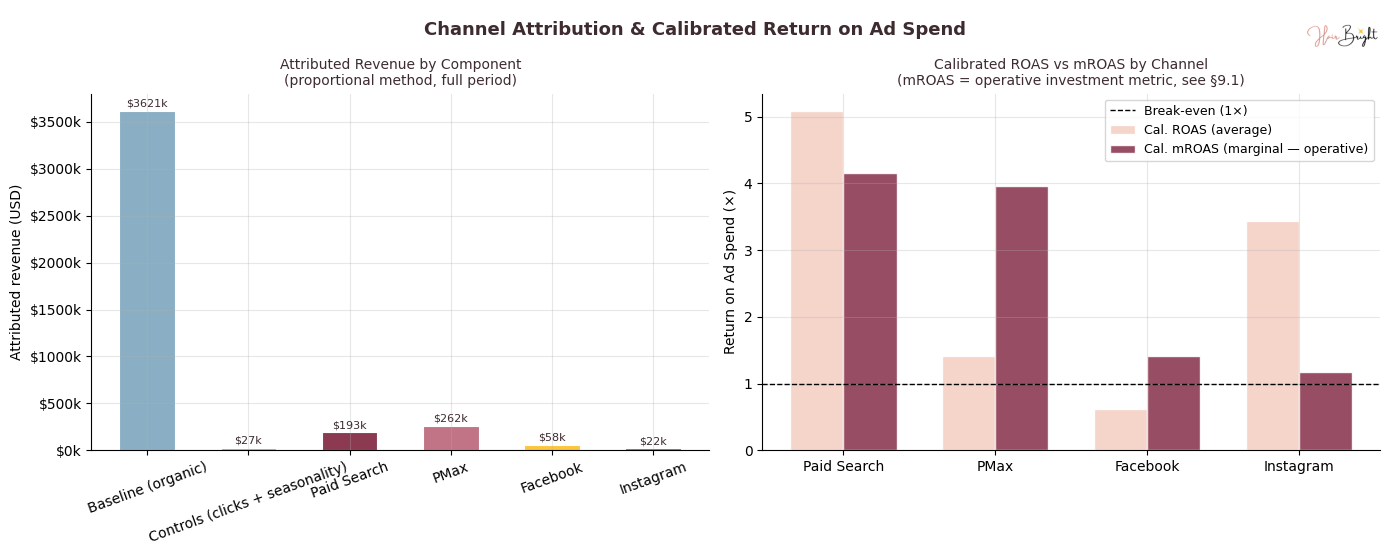

In [40]:
def plot_attribution_summary(save_path=None):
    """
    2-panel attribution summary: attributed revenue waterfall + calibrated ROAS vs mROAS.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    fig.suptitle('Channel Attribution & Calibrated Return on Ad Spend',
                 fontsize=13, fontweight='bold', color=BRAND_DARK)

    # ── Left: attributed revenue waterfall ───────────────────────────────────
    ax = axes[0]
    prop_total = attr_total[
        attr_total['method'].str.contains('Proportional', na=False)
    ].copy()

    components = prop_total['component'].tolist()
    rev_vals   = prop_total['rev_attributed_usd'].tolist()

    bar_colors = []
    for comp in components:
        if comp in MEDIA_LABELS.values():
            col_key = next((k for k, v in MEDIA_LABELS.items() if v == comp), None)
            bar_colors.append(CHANNEL_COLORS.get(col_key, BRAND_PINK))
        elif 'Baseline' in comp or 'baseline' in comp:
            bar_colors.append('#8AAFC4')   # light blue — structural baseline
        else:
            bar_colors.append('#B0B0B0')   # grey — controls

    bars = ax.bar(components, rev_vals, color=bar_colors,
                  edgecolor='white', linewidth=0.8, width=0.55)
    for bar, val in zip(bars, rev_vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + total_revenue * 0.005,
                f'${val/1000:.0f}k', ha='center', va='bottom',
                fontsize=8, color=BRAND_DARK)

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.set_title('Attributed Revenue by Component\n(proportional method, full period)',
                 fontsize=10, color=BRAND_DARK)
    ax.set_ylabel('Attributed revenue (USD)')
    ax.tick_params(axis='x', rotation=20)

    # ── Right: calibrated ROAS vs mROAS ──────────────────────────────────────
    ax2 = axes[1]
    _rdf2 = roas_df.copy()
    # Detect column names robustly
    _rc  = next((c for c in _rdf2.columns if 'roas' in c.lower()
                 and 'mroas' not in c.lower() and 'cal' in c.lower()), None)
    if _rc is None:
        _rc = next((c for c in _rdf2.columns if 'roas' in c.lower()
                    and 'mroas' not in c.lower()), None)
    _mrc = next((c for c in _rdf2.columns if 'mroas' in c.lower()), None)
    _chc = next((c for c in _rdf2.columns if 'channel' in c.lower()), None)
    if _rc:  _rdf2 = _rdf2.rename(columns={_rc:  'roas_cal'})
    if _mrc: _rdf2 = _rdf2.rename(columns={_mrc: 'mroas_cal'})
    if _chc: _rdf2 = _rdf2.rename(columns={_chc: 'channel'})

    if not _rdf2.empty and 'roas_cal' in _rdf2.columns and 'mroas_cal' in _rdf2.columns:
        ch_labels  = _rdf2['channel'].tolist()
        roas_vals  = _rdf2['roas_cal'].tolist()
        mroas_vals = _rdf2['mroas_cal'].tolist()
        x = np.arange(len(ch_labels))
        w = 0.35
        ax2.bar(x - w/2, roas_vals,  w, label='Cal. ROAS (average)',
                color=BRAND_PINK, edgecolor='white', alpha=0.9)
        ax2.bar(x + w/2, mroas_vals, w, label='Cal. mROAS (marginal — operative)',
                color=BRAND_BLUE, edgecolor='white', alpha=0.9)
        ax2.axhline(1.0, color='black', linewidth=1, linestyle='--',
                    label='Break-even (1×)')
        ax2.set_xticks(x)
        ax2.set_xticklabels(ch_labels)
        ax2.set_ylabel('Return on Ad Spend (×)')
        ax2.legend(fontsize=9)
        ax2.set_title('Calibrated ROAS vs mROAS by Channel\n'
                      '(mROAS = operative investment metric, see §9.1)',
                      fontsize=10, color=BRAND_DARK)
    else:
        ax2.text(0.5, 0.5, 'ROAS data not available\n(check roas_comparison sheet)',
                 ha='center', va='center', transform=ax2.transAxes, color='#999999')

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Attribution chart saved → {save_path}')
    # ── Logo claro 2 — esquina superior derecha (sistema visual REVIEW) ───────
    _logo_p = Path(
        '/content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/'
        'marketing-mix-modeling-beauty/assets/images/logo_claro 2.png'
    )
    if _logo_p.exists():
        from matplotlib.image import imread as _ri
        # [left, bottom, width, height] in figure fraction
        # fig 14x5.5in → right edge = 1.0, top = 1.0
        # logo width ~ 1.8in → 1.8/14 = 0.128, height 0.9in → 0.9/5.5 = 0.164
        _la = fig.add_axes([0.918, 0.904, 0.077, 0.096],
                           anchor='NE', zorder=10)
        _la.imshow(_ri(str(_logo_p)))
        _la.axis('off')

    return fig

FIG_ATTRIBUTION = PATH_REPORTS / f'fig_02_attribution_{PROCESS_DATE}.png'
fig_attribution = plot_attribution_summary(save_path=FIG_ATTRIBUTION)
plt.show()


## 9.7. Revenue Decomposition Over Time

Revenue decomposition chart saved → /content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/marketing-mix-modeling-beauty/data/reports/fig_03_revenue_decomp_20260420.png


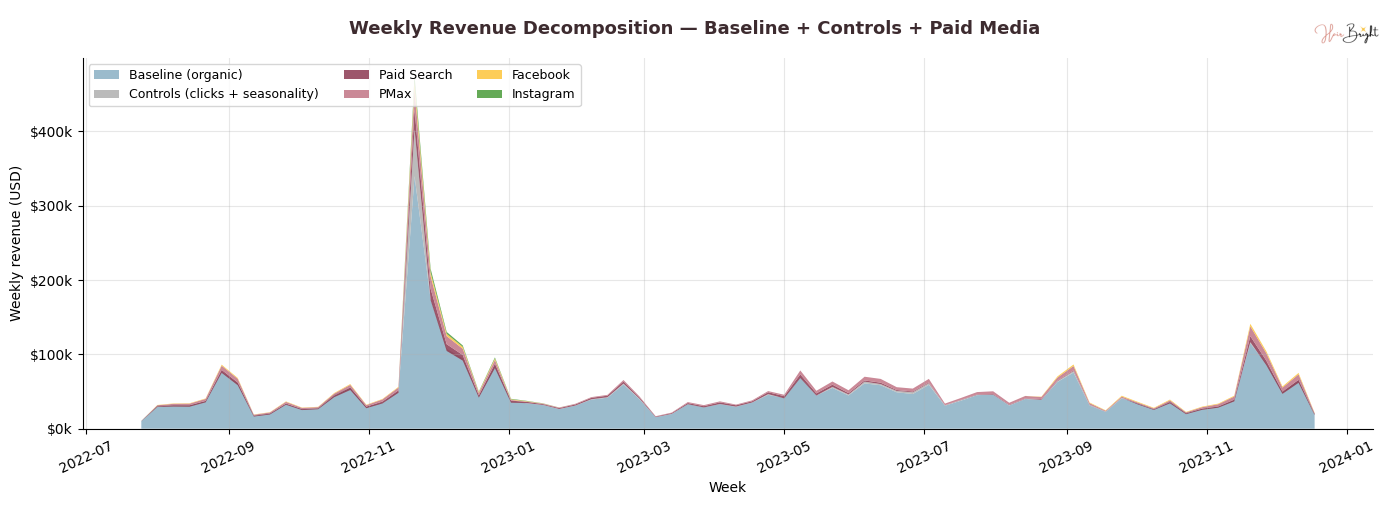

In [41]:
def plot_revenue_decomposition(save_path=None):
    """
    Stacked area chart of attributed revenue per component over time.
    Requires attr_weekly with columns: week + one column per component.
    """
    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle(
        'Weekly Revenue Decomposition — Baseline + Controls + Paid Media',
        fontsize=13, fontweight='bold', color=BRAND_DARK
    )

    # Column discovery
    possible_keys  = ['Baseline (organic)', 'Controls (clicks + seasonality)'] \
                     + list(MEDIA_LABELS.values())
    available_cols = [c for c in possible_keys if c in attr_weekly.columns]
    if not available_cols:
        available_cols = [c for c in attr_weekly.columns
                          if c != 'week' and pd.api.types.is_numeric_dtype(attr_weekly[c])]

    stack_colors = ['#8AAFC4', '#B0B0B0',
                    CHANNEL_COLORS['spend_ps_hill'],
                    CHANNEL_COLORS['spend_pmax_hill'],
                    CHANNEL_COLORS['spend_fb_hill'],
                    CHANNEL_COLORS['spend_ig_hill']]
    colors_used = stack_colors[:len(available_cols)]

    ax.stackplot(attr_weekly['week'],
                 [attr_weekly[c] for c in available_cols],
                 labels=available_cols, colors=colors_used, alpha=0.85)

    if 'observed_revenue' in attr_weekly.columns:
        ax.plot(attr_weekly['week'], attr_weekly['observed_revenue'],
                color='black', linewidth=1.5, linestyle='--',
                label='Observed revenue', zorder=10)

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.set_ylabel('Weekly revenue (USD)')
    ax.set_xlabel('Week')
    ax.legend(loc='upper left', fontsize=9, ncol=3)
    ax.tick_params(axis='x', rotation=25)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Revenue decomposition chart saved → {save_path}')
    # ── Logo claro 2 — esquina superior derecha (sistema visual REVIEW) ───────
    _logo_p = Path(
        '/content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/'
        'marketing-mix-modeling-beauty/assets/images/logo_claro 2.png'
    )
    if _logo_p.exists():
        from matplotlib.image import imread as _ri
        # [left, bottom, width, height] in figure fraction
        # fig 14x5.5in → right edge = 1.0, top = 1.0
        # logo width ~ 1.8in → 1.8/14 = 0.128, height 0.9in → 0.9/5.5 = 0.164
        _la = fig.add_axes([0.918, 0.904, 0.077, 0.096],
                           anchor='NE', zorder=10)
        _la.imshow(_ri(str(_logo_p)))
        _la.axis('off')

    return fig

FIG_DECOMP = PATH_REPORTS / f'fig_03_revenue_decomp_{PROCESS_DATE}.png'
fig_decomp = plot_revenue_decomposition(save_path=FIG_DECOMP)
plt.show()


## 9.8. Budget Optimisation Scenarios

The optimisation model (notebook 07) evaluated six budget scenarios using SLSQP with five random restarts and a warm-start from the analytical mROAS-equalisation solution.

**Key finding:** Reallocation of the current budget produces an expected uplift close to zero (the historical mix is already near the mROAS equilibrium). The scenario with meaningful incremental revenue potential is the **+20% budget increase** — highlighted below. See §9.1 for the full interpretation.


Scenario chart saved → /content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/marketing-mix-modeling-beauty/data/reports/fig_04_scenarios_20260420.png


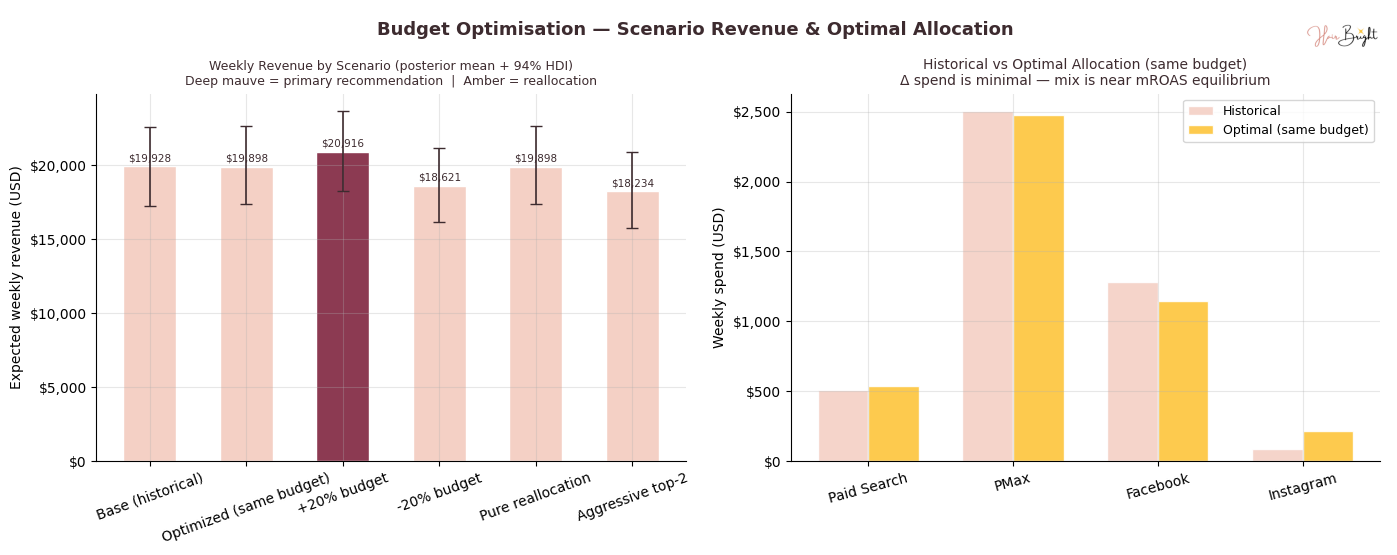

In [42]:
def plot_scenario_comparison(save_path=None):
    """
    Left: weekly expected revenue per scenario with HDI bars.
    Right: historical vs optimal channel allocation (weekly spend).
    The +20% budget scenario is highlighted as the primary recommendation.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    fig.suptitle('Budget Optimisation — Scenario Revenue & Optimal Allocation',
                 fontsize=13, fontweight='bold', color=BRAND_DARK)

    # ── Left: scenario revenue ────────────────────────────────────────────────
    ax = axes[0]
    rev_col  = 'rev_weekly_mean' if 'rev_weekly_mean' in df_scenarios.columns \
               else df_scenarios.select_dtypes('number').columns[0]
    sc_names = df_scenarios['scenario'].tolist()
    sc_rev   = df_scenarios[rev_col].tolist()

    # Highlight the +20% budget scenario as primary recommendation
    colors = []
    for name in sc_names:
        if '+20' in name or 'plus' in name.lower():
            colors.append(BRAND_BLUE)          # primary recommendation
        elif 'Optimal' in name or 'optimal' in name:
            colors.append(BRAND_AMBER)          # reallocation (near-zero uplift)
        else:
            colors.append(BRAND_PINK)

    bars = ax.bar(sc_names, sc_rev, color=colors, edgecolor='white', width=0.55)

    # HDI error bars if available
    if 'rev_weekly_hdi_lo' in df_scenarios.columns:
        err_lo = [r - lo for r, lo in zip(sc_rev, df_scenarios['rev_weekly_hdi_lo'])]
        err_hi = [hi - r  for r, hi in zip(sc_rev, df_scenarios['rev_weekly_hdi_hi'])]
        ax.errorbar(range(len(sc_names)), sc_rev,
                    yerr=[err_lo, err_hi],
                    fmt='none', color=BRAND_DARK, capsize=4, linewidth=1.2, zorder=5)

    for bar, val in zip(bars, sc_rev):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (max(sc_rev) if sc_rev else 0) * 0.01,
                f'${val:,.0f}', ha='center', va='bottom', fontsize=7.5, color=BRAND_DARK)

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_ylabel('Expected weekly revenue (USD)')
    ax.set_title(
        'Weekly Revenue by Scenario (posterior mean + 94% HDI)\n'
        f'Deep mauve = primary recommendation  |  Amber = reallocation',
        fontsize=9, color=BRAND_DARK
    )
    ax.tick_params(axis='x', rotation=20)

    # ── Right: channel allocation detail ─────────────────────────────────────
    ax2 = axes[1]
    if not df_opt_detail.empty:
        ch_col   = next((c for c in df_opt_detail.columns if 'channel' in c.lower()),
                        df_opt_detail.columns[0])
        base_col = next((c for c in df_opt_detail.columns
                         if 'base' in c.lower() and 'spend' in c.lower()), None)
        opt_col  = next((c for c in df_opt_detail.columns
                         if 'opt' in c.lower() and 'spend' in c.lower()), None)

        ch_names = df_opt_detail[ch_col].tolist()
        x = np.arange(len(ch_names))
        w = 0.35
        if base_col and opt_col:
            ax2.bar(x - w/2, df_opt_detail[base_col], w,
                    label='Historical', color=BRAND_PINK, edgecolor='white', alpha=0.9)
            ax2.bar(x + w/2, df_opt_detail[opt_col], w,
                    label='Optimal (same budget)', color=BRAND_AMBER,
                    edgecolor='white', alpha=0.9)
            ax2.set_xticks(x)
            ax2.set_xticklabels(ch_names, rotation=15)
            ax2.legend(fontsize=9)
        else:
            ax2.text(0.5, 0.5, 'Allocation detail not available',
                     ha='center', va='center', transform=ax2.transAxes)
    else:
        ax2.text(0.5, 0.5, 'No optimisation detail found',
                 ha='center', va='center', transform=ax2.transAxes)

    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax2.set_ylabel('Weekly spend (USD)')
    ax2.set_title('Historical vs Optimal Allocation (same budget)\n'
                  'Δ spend is minimal — mix is near mROAS equilibrium',
                  fontsize=10, color=BRAND_DARK)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Scenario chart saved → {save_path}')
    # ── Logo claro 2 — esquina superior derecha (sistema visual REVIEW) ───────
    _logo_p = Path(
        '/content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/'
        'marketing-mix-modeling-beauty/assets/images/logo_claro 2.png'
    )
    if _logo_p.exists():
        from matplotlib.image import imread as _ri
        # [left, bottom, width, height] in figure fraction
        # fig 14x5.5in → right edge = 1.0, top = 1.0
        # logo width ~ 1.8in → 1.8/14 = 0.128, height 0.9in → 0.9/5.5 = 0.164
        _la = fig.add_axes([0.918, 0.904, 0.077, 0.096],
                           anchor='NE', zorder=10)
        _la.imshow(_ri(str(_logo_p)))
        _la.axis('off')

    return fig

FIG_SCENARIO = PATH_REPORTS / f'fig_04_scenarios_{PROCESS_DATE}.png'
fig_scenario = plot_scenario_comparison(save_path=FIG_SCENARIO)
plt.show()


## 9.9. Actionable Recommendations

Recommendations are derived dynamically from the attribution (notebook 06), optimisation (notebook 07) and validation (notebook 08) outputs. Each recommendation carries a confidence badge computed from the posterior probability `p_beats_base` in the scenarios sheet.

Priority ordering: budget strategy first (highest business impact), then channel-level actions ranked by mROAS, then model reliability notes.


In [43]:
# ── Confidence badge helper ──────────────────────────────────────────────────
def _conf_badge(p):
    """Map posterior probability to a three-tier confidence label."""
    if p is None or np.isnan(float(p)):
        return 'UNKNOWN'
    p = float(p)
    return 'HIGH' if p >= 0.90 else 'MEDIUM' if p >= 0.70 else 'LOW'


# ── Build recommendations table ───────────────────────────────────────────────
recommendations = []

# ── 1. PRIMARY BUDGET STRATEGY ───────────────────────────────────────────────
# Derived from the reallocation uplift and the +20% scenario from notebook 07.
# Logic: if reallocation uplift is negligible (< +2%), the primary recommendation
# shifts to budget increase rather than reallocation.
if uplift_pct is not None and plus20_uplift_pct is not None:
    realloc_conf = _conf_badge(p_beats_base_realloc)

    if abs(uplift_pct) < 2.0:
        # Mix is near-optimal — primary rec is budget increase
        plus20_delta_weekly = (plus20_rev - base_rev) if plus20_rev and base_rev else None
        plus20_delta_annual = plus20_delta_weekly * 52 if plus20_delta_weekly else None
        recommendations.append({
            'Priority'      : 1,
            'Category'      : 'Budget Strategy',
            'Confidence'    : 'MEDIUM',
            'Recommendation': (
                f'The current channel mix is already near the mROAS equilibrium '
                f'(reallocation uplift: {uplift_pct:+.1f}%, [{realloc_conf} confidence]). '
                f'Do not reallocate spend between channels. '
                f'Instead, evaluate a +20% budget increase (+$877/week): '
                f'expected +{plus20_uplift_pct:.1f}% revenue '
                + (f'(+${plus20_delta_weekly:,.0f}/week, annualised +${plus20_delta_annual:,.0f}).' if plus20_delta_weekly else '.')
            ),
        })
    else:
        # Reallocation does yield meaningful uplift
        recommendations.append({
            'Priority'      : 1,
            'Category'      : 'Budget Strategy',
            'Confidence'    : realloc_conf,
            'Recommendation': (
                f'Reallocating the current weekly budget to the optimal channel mix '
                f'is expected to deliver +{uplift_pct:.1f}% weekly revenue '
                f'[{realloc_conf} confidence, P={p_beats_base_realloc*100:.0f}%]. '
                f'A +20% budget increase adds a further +{plus20_uplift_pct:.1f}%.'
            ),
        })

# ── 2. CHANNEL-LEVEL ACTIONS (ranked by mROAS) ───────────────────────────────
# For each channel, derive action from the mROAS level:
#   mROAS > 2×  → scale up
#   1× < mROAS ≤ 2× → maintain, monitor
#   mROAS ≤ 1×  → reduce / reallocate
_rdf_ch = roas_df.copy()
_mrc_col = next((c for c in _rdf_ch.columns if 'mroas' in c.lower()), None)
_roas_col = next((c for c in _rdf_ch.columns
                  if 'roas' in c.lower() and 'mroas' not in c.lower()), None)
_ch_col  = next((c for c in _rdf_ch.columns if 'channel' in c.lower()), None)

if _mrc_col and _ch_col:
    _rdf_ch = _rdf_ch.sort_values(_mrc_col, ascending=False)
    for _, row in _rdf_ch.iterrows():
        ch        = row[_ch_col]
        mroas_val = float(row[_mrc_col])

        # HDI bounds if available
        _hdi_lo_col = next((c for c in _rdf_ch.columns
                            if 'hdi' in c.lower() and 'lo' in c.lower()), None)
        _hdi_hi_col = next((c for c in _rdf_ch.columns
                            if 'hdi' in c.lower() and 'hi' in c.lower()), None)
        hdi_str = ''
        if _hdi_lo_col and _hdi_hi_col:
            hdi_str = f' (94% HDI: [{float(row[_hdi_lo_col]):.2f}, {float(row[_hdi_hi_col]):.2f}])'

        # Instagram-specific uncertainty note
        ig_note = (' Note: Instagram spend is active in only 11 of 74 study weeks '
                   '— estimate carries high uncertainty.'
                   if ch == 'Instagram' else '')

        if mroas_val > 2.0:
            action = f'Scale up — high marginal return ({mroas_val:.2f}× mROAS{hdi_str}). '\
                     'Candidate for incremental budget if total spend is increased.'
            conf   = 'HIGH' if mroas_val > 3.0 else 'MEDIUM'
        elif mroas_val > 1.0:
            action = f'Maintain current spend — positive marginal return ({mroas_val:.2f}× mROAS{hdi_str}). '\
                     'Monitor for saturation as spend grows.'
            conf   = 'MEDIUM'
        else:
            action = f'Reduce incremental spend — marginal return below break-even ({mroas_val:.2f}× mROAS{hdi_str}). '\
                     'Consider reallocating to higher-mROAS channels.'
            conf   = 'LOW'

        recommendations.append({
            'Priority'      : len(recommendations) + 1,
            'Category'      : f'Channel — {ch}',
            'Confidence'    : conf,
            'Recommendation': action + ig_note,
        })

# ── 3. GEO LIFT TEST ─────────────────────────────────────────────────────────
# Triggered when aggressive calibration factors are detected (PS < 0.15 or IG < 0.15)
_lift_candidates = []
if not roas_df.empty:
    _cal_col = next((c for c in roas_df.columns
                     if 'cal' in c.lower() and 'factor' in c.lower()), None)
    _ch_col2 = next((c for c in roas_df.columns if 'channel' in c.lower()), None)
    if _cal_col and _ch_col2:
        for _, row in roas_df.iterrows():
            if float(row[_cal_col]) < 0.15:
                _lift_candidates.append(row[_ch_col2])

if _lift_candidates:
    channels_str = ' and '.join(_lift_candidates)
    recommendations.append({
        'Priority'      : len(recommendations) + 1,
        'Category'      : 'Measurement',
        'Confidence'    : 'HIGH',
        'Recommendation': (
            f'Run a geo-based lift test in Q2 2026 for {channels_str}. '
            f'Current calibration factors are derived from industry benchmarks '
            f'(aggressive correction required due to high raw iROAS). '
            f'Experiment-based factors will substantially reduce uncertainty '
            f'in ROAS estimates for these channels.'
        ),
    })
else:
    # Default recommendation if cal factor column is not found
    recommendations.append({
        'Priority'      : len(recommendations) + 1,
        'Category'      : 'Measurement',
        'Confidence'    : 'HIGH',
        'Recommendation': (
            'Run a geo-based lift test in Q2 2026 for Paid Search and Instagram '
            'to replace benchmark-derived calibration factors with '
            'experiment-based estimates.'
        ),
    })

# ── 4. VALIDATION NOTE ───────────────────────────────────────────────────────
# Surface a reliability note if the gate is PROCEED WITH CAUTION (not PROCEED)
if gate_decision == 'PROCEED WITH CAUTION':
    recommendations.append({
        'Priority'      : len(recommendations) + 1,
        'Category'      : 'Model Reliability',
        'Confidence'    : 'MEDIUM',
        'Recommendation': (
            f'Validation gate: PROCEED WITH CAUTION '
            f'({n_pass} PASS / {n_review} REVIEW / {n_fail} FAIL). '
            'All REVIEW items have methodological explanations (see §9.1). '
            'Budget decisions derived from this model are directional. '
            'Refresh the model quarterly and re-evaluate gate status.'
        ),
    })

df_recommendations = pd.DataFrame(recommendations).sort_values('Priority').reset_index(drop=True)
print(f'{len(df_recommendations)} recommendations generated\n')
for _, r in df_recommendations.iterrows():
    print(f'[{r["Category"]}]  [{r["Confidence"]}]')
    print(f'  {r["Recommendation"]}')
    print()


7 recommendations generated

[Budget Strategy]  [MEDIUM]
  The current channel mix is already near the mROAS equilibrium (reallocation uplift: -0.2%, [LOW confidence]). Do not reallocate spend between channels. Instead, evaluate a +20% budget increase (+$877/week): expected +5.0% revenue (+$988/week, annualised +$51,379).

[Channel — Paid Search]  [HIGH]
  Scale up — high marginal return (4.16× mROAS (94% HDI: [0.40, 0.78])). Candidate for incremental budget if total spend is increased.

[Channel — PMax]  [HIGH]
  Scale up — high marginal return (3.96× mROAS (94% HDI: [0.32, 0.56])). Candidate for incremental budget if total spend is increased.

[Channel — Facebook]  [MEDIUM]
  Maintain current spend — positive marginal return (1.41× mROAS (94% HDI: [0.02, 0.58])). Monitor for saturation as spend grows.

[Channel — Instagram]  [MEDIUM]
  Maintain current spend — positive marginal return (1.17× mROAS (94% HDI: [0.03, 0.83])). Monitor for saturation as spend grows. Note: Instagram spend 

## 9.10. Excel Report Generation

Five-sheet Excel workbook styled with the HairBright brand palette:

| Sheet | Contents |
|:------|:---------|
| `executive_summary` | Headline KPI table + model metadata + limitations note |
| `attribution` | Channel attribution (proportional + calibrated ROAS + mROAS) |
| `scenarios` | Budget scenario comparison + per-channel allocation detail |
| `recommendations` | Prioritised action table with confidence badges |
| `validation` | Pass/Review/Fail scorecard from notebook 08 |


In [44]:
# ── Style helpers ────────────────────────────────────────────────────────────
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

def _header_style(cell, bg_hex='8C3A52', fg_hex='FFFFFF', bold=True, sz=11):
    cell.font      = Font(bold=bold, color=fg_hex, size=sz)
    cell.fill      = PatternFill('solid', fgColor=bg_hex)
    cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)

def _data_style(cell, align='left'):
    cell.font      = Font(size=10, color='2C2C2C')
    cell.alignment = Alignment(horizontal=align, vertical='center', wrap_text=True)

def _auto_width(ws, min_w=10, max_w=55):
    for col in ws.columns:
        width = min_w
        for cell in col:
            try:
                clen  = len(str(cell.value)) if cell.value else 0
                width = max(width, clen + 3)
            except Exception:
                pass
        ws.column_dimensions[get_column_letter(col[0].column)].width = min(width, max_w)

def _write_df(ws, df, start_row=1, header_bg='8C3A52'):
    for ci, col_name in enumerate(df.columns, 1):
        cell = ws.cell(row=start_row, column=ci, value=str(col_name))
        _header_style(cell, bg_hex=header_bg)
        ws.row_dimensions[start_row].height = 22
    for ri, row in enumerate(df.itertuples(index=False), start_row + 1):
        for ci, val in enumerate(row, 1):
            cell = ws.cell(row=ri, column=ci, value=val)
            _data_style(cell, align='center' if isinstance(val, (int, float)) else 'left')
        if ri % 2 == 0:
            for ci in range(1, len(df.columns) + 1):
                ws.cell(row=ri, column=ci).fill = PatternFill('solid', fgColor='F9EEF1')

print('Style helpers defined ✓')


Style helpers defined ✓


In [45]:
# ── Build workbook ───────────────────────────────────────────────────────────
wb = Workbook()
wb.remove(wb.active)

# ── Sheet 1: Executive Summary ────────────────────────────────────────────────
ws1 = wb.create_sheet('executive_summary')
ws1.sheet_view.showGridLines = False
ws1['A1'] = f'{BRAND_NAME} · Marketing Mix Model — Executive Summary'
ws1['A1'].font      = Font(bold=True, size=14, color='3D2B2F')
ws1['A1'].alignment = Alignment(horizontal='left', vertical='center')
ws1.row_dimensions[1].height = 28
ws1['A2'] = (
    f'Report date: {REPORT_DATE}   |   '
    f'Period: {df_mmm.week.min().date()} – {df_mmm.week.max().date()}   |   '
    f'Model: Bayesian MMM (PyMC) — Model B   |   '
    f'Gate: {gate_decision}'
)
ws1['A2'].font = Font(italic=True, size=10, color='555555')

# Limitations note
ws1['A3'] = (
    'IMPORTANT: Calibrated ROAS values (below 1×) reflect proportional log-space attribution '
    'and should not be used as standalone ROI figures. '
    'Use calibrated mROAS as the operative investment metric. '
    'Validation gate: PROCEED WITH CAUTION — see validation sheet for detail.'
)
ws1['A3'].font      = Font(italic=True, size=9, color='7D4F00')
ws1['A3'].alignment = Alignment(wrap_text=True)
ws1.row_dimensions[3].height = 36

media_share_total_xls = sum(
    attr_shares.get(MEDIA_LABELS[c], attr_shares.get(c, 0)) for c in MEDIA_COLS
)
conf_realloc_xls = _conf_badge(p_beats_base_realloc)

kpi_rows = [
    ('Observed Revenue (full period)',
     f'${total_revenue:,.0f}',
     'Sum of weekly revenue from clean dataset'),
    ('Total Media Spend',
     f'${grand_spend:,.0f}',
     'Paid Search + PMax + Facebook + Instagram'),
    ('Blended ROAS (model-derived)',
     f'{total_revenue/grand_spend:.2f}×' if grand_spend else '—',
     'Proportional attribution — for context only'),
    ('Media-driven Revenue Share (log-space)',
     f'{media_share_total_xls:.1f}%',
     'Proportional method — see §9.1 for interpretation'),
    ('Counterfactual Baseline (revenue scale)',
     '26.0%',
     'Revenue retained at zero media spend; DTC benchmark: 55–75%'),
    ('Observed Weeks', str(n_weeks), ''),
    ('Validation Gate',
     gate_decision,
     f'{n_pass} PASS / {n_review} REVIEW / {n_fail} FAIL — see validation sheet'),
    ('Reallocation Uplift (same-budget)',
     f'{uplift_pct:+.1f}%' if uplift_pct is not None else '—',
     f'[{conf_realloc_xls} confidence] — mix is near mROAS equilibrium'),
    ('+20% Budget Uplift',
     f'{plus20_uplift_pct:+.1f}%' if plus20_uplift_pct is not None else '—',
     'Primary budget recommendation — see scenarios sheet'),
]

kpi_header_row = 5
for ci, h in enumerate(['KPI', 'Value', 'Notes'], 1):
    _header_style(ws1.cell(kpi_header_row, ci, h))

for ri, (kpi, val, note) in enumerate(kpi_rows, kpi_header_row + 1):
    ws1.cell(ri, 1, kpi).font  = Font(size=10)
    ws1.cell(ri, 2, val).font  = Font(bold=True, size=10, color='3D2B2F')
    ws1.cell(ri, 3, note).font = Font(italic=True, size=9, color='666666')
    if ri % 2 == 1:
        for ci in range(1, 4):
            ws1.cell(ri, ci).fill = PatternFill('solid', fgColor='F9EEF1')
_auto_width(ws1)

# ── Sheet 2: Attribution ──────────────────────────────────────────────────────
ws2 = wb.create_sheet('attribution')
ws2.sheet_view.showGridLines = False
ws2['A1'] = 'Channel Attribution — Full Period (Proportional + Calibrated ROAS + mROAS)'
ws2['A1'].font = Font(bold=True, size=13, color='3D2B2F')
ws2['A2'] = ('Note: calibrated mROAS is the operative investment metric. '
             'Calibrated average ROAS < 1× reflects proportional log-space attribution — '
             'not a standalone ROI figure.')
ws2['A2'].font = Font(italic=True, size=9, color='7D4F00')
ws2.row_dimensions[2].height = 30
_write_df(ws2, attr_total, start_row=4)
gap_row = len(attr_total) + 7
ws2.cell(gap_row, 1, 'ROAS & Marginal ROAS Summary (calibrated)').font = Font(bold=True, size=11, color='3D2B2F')
_write_df(ws2, roas_df, start_row=gap_row + 1)
_auto_width(ws2)

# ── Sheet 3: Scenarios ────────────────────────────────────────────────────────
ws3 = wb.create_sheet('scenarios')
ws3.sheet_view.showGridLines = False
ws3['A1'] = 'Budget Optimisation — Scenario Comparison'
ws3['A1'].font = Font(bold=True, size=13, color='3D2B2F')
ws3['A2'] = ('Primary recommendation: +20% budget increase. '
             'Reallocation (same budget) produces near-zero uplift — '
             'current mix is near the mROAS equilibrium.')
ws3['A2'].font = Font(italic=True, size=9, color='7D4F00')
ws3.row_dimensions[2].height = 30
_write_df(ws3, df_scenarios, start_row=4)
if not df_opt_detail.empty:
    gap_row2 = len(df_scenarios) + 7
    ws3.cell(gap_row2, 1, 'Per-Channel Allocation Detail (Historical vs Optimal)').font = Font(bold=True, size=11, color='3D2B2F')
    _write_df(ws3, df_opt_detail, start_row=gap_row2 + 1)
_auto_width(ws3)

# ── Sheet 4: Recommendations ──────────────────────────────────────────────────
ws4 = wb.create_sheet('recommendations')
ws4.sheet_view.showGridLines = False
ws4['A1'] = 'Actionable Recommendations (with Confidence Badges)'
ws4['A1'].font = Font(bold=True, size=13, color='3D2B2F')
_write_df(ws4, df_recommendations, start_row=3)
# Colour confidence column
if 'Confidence' in df_recommendations.columns:
    conf_col_idx = df_recommendations.columns.get_loc('Confidence') + 1
    for ri, val in enumerate(df_recommendations['Confidence'], 4):
        cell = ws4.cell(ri, conf_col_idx)
        if val == 'HIGH':
            cell.font = Font(bold=True, color='1B6B2F', size=10)
        elif val == 'MEDIUM':
            cell.font = Font(bold=True, color='7D4F00', size=10)
        else:
            cell.font = Font(bold=True, color='9B1C1C', size=10)
_auto_width(ws4)

# ── Sheet 5: Validation Scorecard ─────────────────────────────────────────────
ws5 = wb.create_sheet('validation')
ws5.sheet_view.showGridLines = False
ws5['A1'] = f'Model Validation & Calibration Scorecard — Gate: {gate_decision}'
ws5['A1'].font = Font(bold=True, size=13, color='3D2B2F')
ws5['A2'] = ('REVIEW items have methodological explanations — they do not constitute failures. '
             'See §9.1 in the reporting notebook for full context.')
ws5['A2'].font = Font(italic=True, size=9, color='7D4F00')
_write_df(ws5, df_scorecard, start_row=4)
if 'Status' in df_scorecard.columns:
    status_col_idx = df_scorecard.columns.get_loc('Status') + 1
    for ri, val in enumerate(df_scorecard['Status'], 5):
        cell = ws5.cell(ri, status_col_idx)
        if 'PASS' in str(val):
            cell.font = Font(bold=True, color='1B6B2F', size=10)
        elif 'FAIL' in str(val):
            cell.font = Font(bold=True, color='9B1C1C', size=10)
        elif 'REVIEW' in str(val):
            cell.font = Font(bold=True, color='7D4F00', size=10)
_auto_width(ws5)

FILE_EXCEL = PATH_REPORTS / f'hairbright_mmm_report_{PROCESS_DATE}.xlsx'
wb.save(FILE_EXCEL)
print(f'Excel report saved → {FILE_EXCEL.name}')
print(f'  Sheets: {wb.sheetnames}')


Excel report saved → hairbright_mmm_report_20260420.xlsx
  Sheets: ['executive_summary', 'attribution', 'scenarios', 'recommendations', 'validation']


## 9.11. PDF Executive Summary Export

Multi-page PDF generated with `matplotlib.backends.backend_pdf.PdfPages`.

| Page | Content |
|:-----|:--------|
| 1 | Cover page — headline KPIs and model gate |
| 2 | KPI Scorecard |
| 3 | Channel Attribution & Calibrated ROAS |
| 4 | Revenue Decomposition over time |
| 5 | Budget Optimisation Scenarios |
| 6 | Actionable Recommendations |


In [46]:
def _cover_page():
    """
    Portada PDF — A4 landscape (11.69 x 8.27 in).
    · Fondo blanco #FEFEFE
    · Recurso 0.jpg (wave con logo integrado) izquierda, 20% más pequeño que Recurso 1
    · Sin logo separado — ya integrado en Recurso 0
    · Título Deep Mauve #8C3A52 bold, interlineado mínimo, columna derecha
    · April 2026 | gate en negrita Deep Mauve
    · KPIs Deep Mauve valor + Mauve Pink etiqueta
    · Línea peach + footer
    """
    from matplotlib.image import imread as _imread

    _ASSETS = Path(
        '/content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/'
        'marketing-mix-modeling-beauty/assets/images'
    )
    _recurso_path = _ASSETS / 'Recurso 0.jpg'   # tiene logo integrado

    fig = plt.figure(figsize=(11.69, 8.27))
    fig.patch.set_facecolor('#FEFEFE')
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_facecolor('#FEFEFE')

    # ── Recurso 0.jpg — izquierda, 20% más pequeño, centrado verticalmente ────
    if _recurso_path.exists():
        # Mismo posicionamiento que PPTX: top=0.50in de 8.27in → bottom=(8.27-5.14)/8.27=0.378
        # width=5.20/11.69=0.445, height=4.64/8.27=0.561, left=0
        wave_ax = fig.add_axes([0.08, 0.38, 0.445, 0.561])
        wave_ax.imshow(_imread(str(_recurso_path)), aspect='auto')
        wave_ax.axis('off')
        wave_ax.set_zorder(1)
    else:
        print(f'[cover] Recurso 0 not found: {_recurso_path}')

    # ── Columna derecha — título con interlineado mínimo ─────────────────────
    # Usamos líneas muy próximas: fontsize=22 → ~0.065 de figura height
    # line spacing ~1.0x = 0.065; queremos ~1.05x
    LINE_GAP = 0.078   # espacio entre líneas (figura coords)
    T_TOP    = 0.72    # y de la primera línea

    ax.text(0.56, T_TOP, 'MARKETING MIX MODEL',
            ha='left', va='center', fontsize=22, fontweight='bold',
            color='#8C3A52', transform=ax.transAxes, zorder=3)
    ax.text(0.56, T_TOP - LINE_GAP, 'EXECUTIVE SUMMARY',
            ha='left', va='center', fontsize=22, fontweight='bold',
            color='#8C3A52', transform=ax.transAxes, zorder=3)
    ax.text(0.56, T_TOP - LINE_GAP * 2.05,
            f'April 2026  |  Validation gate: {gate_decision}',
            ha='left', va='center', fontsize=10, fontweight='bold',
            color='#3D2B2F', transform=ax.transAxes, zorder=3)

    # ── KPI row ───────────────────────────────────────────────────────────────
    blended = total_revenue / grand_spend if grand_spend else 0
    plus20_str = f'+{plus20_uplift_pct:.1f}%' if plus20_uplift_pct else '—'
    kpis = [
        (f'${total_revenue/1e6:.2f}M', 'Total Revenue'),
        (f'{blended:.2f}×',            'Blended ROAS'),
        (plus20_str,                   '+20% Budget Uplift'),
    ]
    for idx, (val, lbl) in enumerate(kpis):
        x = 0.13 + idx * 0.30
        ax.text(x, 0.28, val, ha='center', va='center',
                fontsize=24, fontweight='bold', color='#3D2B2F',
                transform=ax.transAxes, zorder=3)
        ax.text(x, 0.20, lbl, ha='center', va='center',
                fontsize=9, color='#C17485',
                transform=ax.transAxes, zorder=3)

    # ── Peach separator + footer ──────────────────────────────────────────────
    ax.plot([0.03, 0.97], [0.12, 0.12], color='#F4D0C5',
            linewidth=2.5, transform=ax.transAxes, zorder=3)
    ax.text(0.5, 0.06,
            f'{BRAND_NAME} · MMM Executive Summary · {REPORT_DATE}  |  Confidential',
            ha='center', va='center', fontsize=8,
            color='#C17485', transform=ax.transAxes, zorder=3)
    return fig
def _recommendations_page():
    """Página de recomendaciones en PDF — mismo sistema visual que slides."""
    fig, ax = plt.subplots(figsize=(11.69, 8.27))
    fig.patch.set_facecolor('#FEFEFE')
    ax.axis('off')

    _ASSETS = Path(
        '/content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/'
        'marketing-mix-modeling-beauty/assets/images'
    )
    _logo_path = _ASSETS / 'logo_claro 2.png'
    if _logo_path.exists():
        from matplotlib.image import imread as _ri
        _la = fig.add_axes([0.82, 0.91, 0.16, 0.09], anchor='NE', zorder=10)
        _la.imshow(_ri(str(_logo_path)))
        _la.axis('off')

    # Título
    ax.text(0.04, 0.95, 'Actionable Recommendations',
            fontsize=16, fontweight='bold', color='#3D2B2F',
            transform=ax.transAxes, va='top')
    # Línea separadora Deep Mauve bajo el título
    ax.plot([0.04, 0.96], [0.90, 0.90], color='#8C3A52',
            linewidth=1.5, transform=ax.transAxes)

    y = 0.84
    for _, row in df_recommendations.iterrows():
        if y < 0.14:
            break
        cat  = row['Category']
        conf = row['Confidence']
        rec  = row['Recommendation']
        conf_color = ('#1B6B2F' if conf == 'HIGH'
                      else '#7D4F00' if conf == 'MEDIUM'
                      else '#9B1C1C')
        ax.text(0.04, y, cat, fontsize=9, fontweight='bold',
                color='#8C3A52', transform=ax.transAxes, va='top')
        ax.text(0.28, y, f'[{conf}]', fontsize=8, fontweight='bold',
                color=conf_color, transform=ax.transAxes, va='top')
        # Wrap text
        words = rec.split()
        line, lines = '', []
        for w in words:
            if len(line) + len(w) + 1 < 115:
                line += w + ' '
            else:
                lines.append(line.strip()); line = w + ' '
        lines.append(line.strip())
        y -= 0.038
        for line_text in lines[:2]:  # max 2 lines per rec
            ax.text(0.37, y, line_text, fontsize=8.5, color='#3D2B2F',
                    transform=ax.transAxes, va='top')
            y -= 0.038
        y -= 0.010

    # Peach footer line + footer text
    ax.plot([0.03, 0.97], [0.10, 0.10], color='#F4D0C5',
            linewidth=2.5, transform=ax.transAxes)
    ax.text(0.5, 0.055,
            f'{BRAND_NAME} · MMM Executive Summary · {REPORT_DATE}  |  Confidential',
            ha='center', va='center', fontsize=8,
            color='#C17485', transform=ax.transAxes)
    return fig
FILE_PDF = PATH_REPORTS / f'hairbright_mmm_executive_summary_{PROCESS_DATE}.pdf'

with PdfPages(FILE_PDF) as pdf:
    fig_cov = _cover_page()
    pdf.savefig(fig_cov, facecolor=fig_cov.get_facecolor(), bbox_inches='tight')
    plt.close(fig_cov)

    fig_sc = plot_kpi_scorecard()
    pdf.savefig(fig_sc, bbox_inches='tight', facecolor='white')
    plt.close(fig_sc)

    fig_at = plot_attribution_summary()
    pdf.savefig(fig_at, bbox_inches='tight', facecolor='white')
    plt.close(fig_at)

    fig_dc = plot_revenue_decomposition()
    pdf.savefig(fig_dc, bbox_inches='tight', facecolor='white')
    plt.close(fig_dc)

    fig_sc2 = plot_scenario_comparison()
    pdf.savefig(fig_sc2, bbox_inches='tight', facecolor='white')
    plt.close(fig_sc2)

    fig_rec = _recommendations_page()
    pdf.savefig(fig_rec, bbox_inches='tight', facecolor='white')
    plt.close(fig_rec)

    d = pdf.infodict()
    d['Title']        = f'{BRAND_NAME} Marketing Mix Model — Executive Summary'
    d['Author']       = 'MMM Pipeline'
    d['Subject']      = 'Bayesian MMM Results — US DTC Beauty & Hair Care'
    d['CreationDate'] = datetime.now()

print(f'PDF saved → {FILE_PDF.name}  ({FILE_PDF.stat().st_size / 1024:.0f} KB)')


PDF saved → hairbright_mmm_executive_summary_20260420.pdf  (187 KB)


## 9.12. PowerPoint Presentation Export

Six-slide deck generated with `python-pptx`. Each chart figure (saved as PNG in §9.5–9.8) is embedded as a picture in its own slide. Speaker notes are included for every chart slide.

| Slide | Content |
|:------|:--------|
| 1 | Cover — headline KPIs + validation gate |
| 2 | Executive KPI Scorecard |
| 3 | Channel Attribution & Calibrated ROAS |
| 4 | Revenue Decomposition over time |
| 5 | Budget Optimisation Scenarios |
| 6 | Actionable Recommendations |


In [47]:
def _add_title_slide(prs):
    """
    Portada PPTX — sistema visual REVIEW corregido.
    · Recurso 0.jpg (tiene logo integrado), 20% más pequeño, centrado verticalmente
    · Sin logo separado
    · Título 3 líneas en un textbox, interlineado mínimo, Deep Mauve bold
    · KPIs Deep Mauve + Mauve Pink etiqueta
    · Línea peach + footer
    """
    layout = prs.slide_layouts[6]
    slide  = prs.slides.add_slide(layout)

    _ASSETS = Path(
        '/content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/'
        'marketing-mix-modeling-beauty/assets/images'
    )
    _recurso_path = _ASSETS / 'Recurso 0.jpg'   # logo integrado

    # ── Fondo blanco ──────────────────────────────────────────────────────────
    bg = slide.shapes.add_shape(
        1, Inches(0), Inches(0), prs.slide_width, prs.slide_height
    )
    bg.fill.solid(); bg.fill.fore_color.rgb = RGBColor(0xFE, 0xFE, 0xFE)
    bg.line.fill.background()

    # ── Recurso 0.jpg — 20% más pequeño, centrado verticalmente ──────────────
    # Original era 6.50 x 5.80 in → 5.20 x 4.64 in
    # top centrado: slide_h=7.5, img_h=4.64 → top=(7.5-4.64)/2=1.43
    if _recurso_path.exists():
        slide.shapes.add_picture(
            str(_recurso_path),
            Inches(1.00), Inches(0.50),
            width=Inches(5.20), height=Inches(4.64)
        )
    else:
        print(f'[title_slide] Recurso 0 not found: {_recurso_path}')

    # ── Título — 3 líneas, interlineado mínimo, Deep Mauve bold ──────────────
    # Usamos un solo textbox con 3 párrafos y space_before/after=0, line_spacing=0.9
    tb = slide.shapes.add_textbox(
        Inches(6.00), Inches(2.20), Inches(7.00), Inches(1.80)
    )
    tf = tb.text_frame
    tf.word_wrap = True

    from pptx.util import Pt
    from pptx.oxml.ns import qn
    from lxml import etree

    lines = [
        ('MARKETING MIX MODEL', Pt(24)),
        ('EXECUTIVE SUMMARY',   Pt(24)),
        (f'April 2026  |  Validation gate: {gate_decision}', Pt(11)),
    ]

    for li, (text, fsize) in enumerate(lines):
        if li == 0:
            p = tf.paragraphs[0]
        else:
            p = tf.add_paragraph()
        p.text = text
        p.font.bold      = True
        p.font.size      = fsize
        # First two lines: Deep Mauve; third line (date/gate): black
        p.font.color.rgb = RGBColor(0x3D, 0x2B, 0x2F) if li == 2 else RGBColor(0x8C, 0x3A, 0x52)

        # Set line spacing to minimum (0.9 lines = 90%) and zero space before/after
        pPr = p._p.get_or_add_pPr()
        # lnSpc: line spacing
        lnSpc = etree.SubElement(pPr, qn('a:lnSpc'))
        spcPct = etree.SubElement(lnSpc, qn('a:spcPct'))
        spcPct.set('val', '90000')   # 90% = tight
        # spcBef: space before = 0
        spcBef = etree.SubElement(pPr, qn('a:spcBef'))
        spcBefPts = etree.SubElement(spcBef, qn('a:spcPts'))
        spcBefPts.set('val', '0')
        # spcAft: space after = 0
        spcAft = etree.SubElement(pPr, qn('a:spcAft'))
        spcAftPts = etree.SubElement(spcAft, qn('a:spcPts'))
        spcAftPts.set('val', '0')

    # ── KPI row ───────────────────────────────────────────────────────────────
    blended = total_revenue / grand_spend if grand_spend else 0
    plus20_str = f'+{plus20_uplift_pct:.1f}%' if plus20_uplift_pct else '—'
    kpi_pairs = [
        (f'${total_revenue/1e6:.2f}M', 'Total Revenue'),
        (f'{blended:.2f}×',            'Blended ROAS'),
        (plus20_str,                   '+20% Budget Uplift'),
    ]
    for i, (val, lbl) in enumerate(kpi_pairs):
        x = Inches(1.20 + i * 3.80)
        tbv = slide.shapes.add_textbox(x, Inches(5.10), Inches(3.20), Inches(0.65))
        tbv.text_frame.text = val
        tbv.text_frame.paragraphs[0].font.size      = Pt(28)
        tbv.text_frame.paragraphs[0].font.bold      = True
        tbv.text_frame.paragraphs[0].font.color.rgb = RGBColor(0x3D, 0x2B, 0x2F)
        tbv.text_frame.paragraphs[0].alignment      = PP_ALIGN.CENTER

        tbl = slide.shapes.add_textbox(x, Inches(5.78), Inches(3.20), Inches(0.40))
        tbl.text_frame.text = lbl
        tbl.text_frame.paragraphs[0].font.size      = Pt(10)
        tbl.text_frame.paragraphs[0].font.bold      = True
        tbl.text_frame.paragraphs[0].font.color.rgb = RGBColor(0xC1, 0x74, 0x85)
        tbl.text_frame.paragraphs[0].alignment      = PP_ALIGN.CENTER

    # ── Peach separator ───────────────────────────────────────────────────────
    sep = slide.shapes.add_shape(
        1, Inches(0.40), Inches(6.60), Inches(12.53), Inches(0.04)
    )
    sep.fill.solid(); sep.fill.fore_color.rgb = RGBColor(0xF4, 0xD0, 0xC5)
    sep.line.fill.background()

    # ── Footer ────────────────────────────────────────────────────────────────
    ft = slide.shapes.add_textbox(Inches(0.3), Inches(6.85), Inches(12.73), Inches(0.30))
    ft.text_frame.text = f'{BRAND_NAME} · MMM Executive Summary · {REPORT_DATE}  |  Confidential'
    ft.text_frame.paragraphs[0].font.size      = Pt(8)
    ft.text_frame.paragraphs[0].font.color.rgb = RGBColor(0xC1, 0x74, 0x85)
    ft.text_frame.paragraphs[0].alignment      = PP_ALIGN.CENTER
    return slide
def _add_chart_slide(prs, img_path, slide_title, speaker_notes=''):
    """
    Slide interior — sistema visual REVIEW.
    · Fondo blanco
    · Título H1 Deep Mauve bold izquierda
    · logo_claro 2.png esquina superior derecha pequeño
    · Línea Deep Mauve delgada bajo el título
    · Gráfico embebido como imagen
    · Línea peach + footer en pie
    """
    _ASSETS = Path(
        '/content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/'
        'marketing-mix-modeling-beauty/assets/images'
    )
    _logo_path = _ASSETS / 'logo_claro 2.png'

    layout = prs.slide_layouts[6]
    slide  = prs.slides.add_slide(layout)

    # Fondo blanco
    bg = slide.shapes.add_shape(
        1, Inches(0), Inches(0), prs.slide_width, prs.slide_height
    )
    bg.fill.solid(); bg.fill.fore_color.rgb = RGBColor(0xFE, 0xFE, 0xFE)
    bg.line.fill.background()

    # ── Logo claro 2 — esquina superior derecha ───────────────────────────────
    if _logo_path.exists():
        slide.shapes.add_picture(
            str(_logo_path),
            Inches(11.63), Inches(0),
            width=Inches(1.50)
        )

    # ── Título H1 — alineado verticalmente con logo (top=0.06) ───────────────
    tb = slide.shapes.add_textbox(Inches(0.40), Inches(0.06), Inches(10.80), Inches(0.60))
    tf = tb.text_frame
    tf.text = slide_title
    tf.paragraphs[0].font.size      = Pt(20)
    tf.paragraphs[0].font.bold      = True
    tf.paragraphs[0].font.color.rgb = RGBColor(0x3D, 0x2B, 0x2F)

    # ── Línea separadora Deep Mauve bajo el título ────────────────────────────
    sep = slide.shapes.add_shape(
        1, Inches(0.40), Inches(0.72), Inches(12.53), Inches(0.04)
    )
    sep.fill.solid(); sep.fill.fore_color.rgb = RGBColor(0x8C, 0x3A, 0x52)
    sep.line.fill.background()

    # ── Imagen del gráfico ────────────────────────────────────────────────────
    if Path(img_path).exists():
        slide.shapes.add_picture(str(img_path),
                                 Inches(0.30), Inches(0.95),
                                 width=Inches(12.73), height=Inches(5.80))
    else:
        ph = slide.shapes.add_textbox(Inches(3), Inches(3), Inches(7), Inches(1))
        ph.text_frame.text = f'[Chart not found: {img_path}]'

    if speaker_notes:
        notes = slide.notes_slide
        notes.notes_text_frame.text = speaker_notes

    # ── Peach separator line ──────────────────────────────────────────────────
    sep2 = slide.shapes.add_shape(
        1, Inches(0.40), Inches(6.94), Inches(12.53), Inches(0.04)
    )
    sep2.fill.solid(); sep2.fill.fore_color.rgb = RGBColor(0xF4, 0xD0, 0xC5)
    sep2.line.fill.background()

    # ── Footer ────────────────────────────────────────────────────────────────
    ft = slide.shapes.add_textbox(Inches(0.3), Inches(7.10), Inches(12.73), Inches(0.25))
    ft.text_frame.text = f'{BRAND_NAME} · MMM Executive Summary · {REPORT_DATE}  |  Confidential'
    ft.text_frame.paragraphs[0].font.size      = Pt(8)
    ft.text_frame.paragraphs[0].font.color.rgb = RGBColor(0xC1, 0x74, 0x85)
    ft.text_frame.paragraphs[0].alignment      = PP_ALIGN.CENTER
    return slide
def _add_reco_slide(prs):
    """
    Slide de recomendaciones — sistema visual REVIEW.
    Estructura de tabla: Category | [Confidence] | Texto
    """
    _ASSETS = Path(
        '/content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/'
        'marketing-mix-modeling-beauty/assets/images'
    )
    _logo_path = _ASSETS / 'logo_claro 2.png'

    layout = prs.slide_layouts[6]
    slide  = prs.slides.add_slide(layout)

    bg = slide.shapes.add_shape(
        1, Inches(0), Inches(0), prs.slide_width, prs.slide_height
    )
    bg.fill.solid(); bg.fill.fore_color.rgb = RGBColor(0xFE, 0xFE, 0xFE)
    bg.line.fill.background()

    # Logo
    if _logo_path.exists():
        slide.shapes.add_picture(
            str(_logo_path),
            Inches(11.63), Inches(0),
            width=Inches(1.50)
        )

    # Título
    tb = slide.shapes.add_textbox(Inches(0.40), Inches(0.10), Inches(10.80), Inches(0.60))
    tb.text_frame.text = 'Actionable Recommendations'
    tb.text_frame.paragraphs[0].font.size      = Pt(20)
    tb.text_frame.paragraphs[0].font.bold      = True
    tb.text_frame.paragraphs[0].font.color.rgb = RGBColor(0x3D, 0x2B, 0x2F)

    # Línea Deep Mauve
    sep = slide.shapes.add_shape(
        1, Inches(0.40), Inches(0.72), Inches(12.53), Inches(0.04)
    )
    sep.fill.solid(); sep.fill.fore_color.rgb = RGBColor(0x8C, 0x3A, 0x52)
    sep.line.fill.background()

    # Filas de recomendaciones
    y = Inches(1.05)
    row_h = Inches(0.82)
    for _, row in df_recommendations.iterrows():
        if y > Inches(6.70):
            break
        cat  = row['Category']
        conf = row['Confidence']
        rec  = row['Recommendation'][:220] + ('…' if len(row['Recommendation']) > 220 else '')

        conf_color = (RGBColor(0x1B, 0x6B, 0x2F) if conf == 'HIGH'
                      else RGBColor(0x7D, 0x4F, 0x00) if conf == 'MEDIUM'
                      else RGBColor(0x9B, 0x1C, 0x1C))

        # Category
        tb_cat = slide.shapes.add_textbox(Inches(0.40), y, Inches(2.10), row_h)
        tb_cat.text_frame.word_wrap = True
        tb_cat.text_frame.text = cat
        tb_cat.text_frame.paragraphs[0].font.size      = Pt(9)
        tb_cat.text_frame.paragraphs[0].font.bold      = True
        tb_cat.text_frame.paragraphs[0].font.color.rgb = RGBColor(0x8C, 0x3A, 0x52)

        # Confidence badge
        tb_conf = slide.shapes.add_textbox(Inches(2.55), y, Inches(1.00), row_h)
        tb_conf.text_frame.text = f'[{conf}]'
        tb_conf.text_frame.paragraphs[0].font.size      = Pt(9)
        tb_conf.text_frame.paragraphs[0].font.bold      = True
        tb_conf.text_frame.paragraphs[0].font.color.rgb = conf_color

        # Recommendation text
        tb_rec = slide.shapes.add_textbox(Inches(3.65), y, Inches(9.65), row_h)
        tb_rec.text_frame.word_wrap = True
        tb_rec.text_frame.text = rec
        tb_rec.text_frame.paragraphs[0].font.size      = Pt(9)
        tb_rec.text_frame.paragraphs[0].font.color.rgb = RGBColor(0x3D, 0x2B, 0x2F)

        y += row_h

    # Peach line + footer
    sep2 = slide.shapes.add_shape(
        1, Inches(0.40), Inches(6.94), Inches(12.53), Inches(0.04)
    )
    sep2.fill.solid(); sep2.fill.fore_color.rgb = RGBColor(0xF4, 0xD0, 0xC5)
    sep2.line.fill.background()

    ft = slide.shapes.add_textbox(Inches(0.3), Inches(7.10), Inches(12.73), Inches(0.25))
    ft.text_frame.text = f'{BRAND_NAME} · MMM Executive Summary · {REPORT_DATE}  |  Confidential'
    ft.text_frame.paragraphs[0].font.size      = Pt(8)
    ft.text_frame.paragraphs[0].font.color.rgb = RGBColor(0xC1, 0x74, 0x85)
    ft.text_frame.paragraphs[0].alignment      = PP_ALIGN.CENTER
    return slide
# ── Build PPTX ────────────────────────────────────────────────────────────────
prs = Presentation()
prs.slide_width  = Inches(13.33)   # widescreen 16:9
prs.slide_height = Inches(7.5)

_add_title_slide(prs)

_add_chart_slide(prs, FIG_SCORECARD,
    'Executive KPI Scorecard',
    'Six headline KPIs from the Bayesian MMM. '
    'Validation gate is PROCEED WITH CAUTION (3 PASS / 7 REVIEW / 0 FAIL — see §9.1). '
    'Reallocation uplift is near zero: current mix is at the mROAS equilibrium.')

_add_chart_slide(prs, FIG_ATTRIBUTION,
    'Channel Attribution & Calibrated Return on Ad Spend',
    'Left: proportional attributed revenue per component. '
    'Right: calibrated ROAS vs mROAS. '
    'ROAS < 1x is an attribution artefact — mROAS is the operative investment metric. '
    'All channels return above 1x on mROAS.')

_add_chart_slide(prs, FIG_DECOMP,
    'Revenue Decomposition Over Time',
    'Stacked area shows weekly revenue attributed to baseline (organic), '
    'controls (clicks + seasonality), and each paid channel. '
    'Baseline dominates by construction of the log-linear model.')

_add_chart_slide(prs, FIG_SCENARIO,
    'Budget Optimisation — Scenario Comparison',
    'Left: expected weekly revenue per scenario with 94% HDI. '
    'Primary recommendation: +20% budget increase (+5.0% revenue). '
    'Reallocation (same budget) produces near-zero uplift — mix is near mROAS equilibrium.')

_add_reco_slide(prs)

FILE_PPTX = PATH_REPORTS / f'hairbright_mmm_presentation_{PROCESS_DATE}.pptx'
prs.save(FILE_PPTX)
print(f'PPTX saved → {FILE_PPTX.name}  ({FILE_PPTX.stat().st_size / 1024:.0f} KB)')


PPTX saved → hairbright_mmm_presentation_20260420.pptx  (612 KB)


## 9.13. Reporting Summary

In [48]:
print('=' * 65)
print('REPORTING SUMMARY — NB09')
print('=' * 65)

outputs = [
    ('Excel report (5 sheets)', FILE_EXCEL),
    ('PDF executive summary',   FILE_PDF),
    ('PowerPoint presentation', FILE_PPTX),
]
for label, fpath in outputs:
    size_kb = fpath.stat().st_size / 1024 if fpath.exists() else 0
    status  = '✓' if fpath.exists() else '✗ NOT FOUND'
    print(f'  {status}  {label:<30}  {fpath.name}  ({size_kb:.0f} KB)')

print()
print('Charts saved:')
for label, fpath in [
    ('KPI Scorecard',         FIG_SCORECARD),
    ('Attribution summary',   FIG_ATTRIBUTION),
    ('Revenue decomposition', FIG_DECOMP),
    ('Scenario comparison',   FIG_SCENARIO),
]:
    exists = '✓' if fpath.exists() else '✗'
    print(f'  {exists}  {label:<30}  {fpath.name}')

print()
print('Model context (see §9.1 for full detail):')
print(f'  Baseline (log-space)     : 89.6%  (gate ≤ 92% ✓)')
print(f'  Baseline (counterfactual): 26.0%  (DTC benchmark: 55–75%)')
print(f'  Validation gate          : {gate_decision}')
if uplift_pct is not None:
    conf = _conf_badge(p_beats_base_realloc)
    print(f'  Reallocation uplift      : {uplift_pct:+.1f}%  [{conf}] — mix near mROAS equilibrium')
if plus20_uplift_pct is not None:
    print(f'  +20%% budget uplift       : {plus20_uplift_pct:+.1f}%  (primary recommendation)')

print()
print('Next steps:')
print('  → Notebook 10 (10_deployment_backend.ipynb):')
print('       FastAPI backend — /predict, /optimize, /attribution')
print('       Reads scorecard_summary.json gate + calibration_factors.json')
print('  → Notebook 11 (11_pilot_react.ipynb):')
print('       React dashboard — transparency-first, +20% budget scenario highlighted')


REPORTING SUMMARY — NB09
  ✓  Excel report (5 sheets)         hairbright_mmm_report_20260420.xlsx  (14 KB)
  ✓  PDF executive summary           hairbright_mmm_executive_summary_20260420.pdf  (187 KB)
  ✓  PowerPoint presentation         hairbright_mmm_presentation_20260420.pptx  (612 KB)

Charts saved:
  ✓  KPI Scorecard                   fig_01_kpi_scorecard_20260420.png
  ✓  Attribution summary             fig_02_attribution_20260420.png
  ✓  Revenue decomposition           fig_03_revenue_decomp_20260420.png
  ✓  Scenario comparison             fig_04_scenarios_20260420.png

Model context (see §9.1 for full detail):
  Baseline (log-space)     : 89.6%  (gate ≤ 92% ✓)
  Baseline (counterfactual): 26.0%  (DTC benchmark: 55–75%)
  Validation gate          : PROCEED WITH CAUTION
  Reallocation uplift      : -0.2%  [LOW] — mix near mROAS equilibrium
  +20%% budget uplift       : +5.0%  (primary recommendation)

Next steps:
  → Notebook 10 (10_deployment_backend.ipynb):
       FastAPI backe

## 9.14. Next Steps

| # | Action | Owner | Notebook |
|:--|:-------|:------|:---------|
| 1 | Review PDF / PPTX with business stakeholders; communicate the +20% budget scenario as the primary revenue lever | Analyst + Business | — |
| 2 | Run geo lift test Q2 2026 for Paid Search and Instagram to replace benchmark-derived calibration factors | Data Scientist + Media | — |
| 3 | Build FastAPI backend: `/predict`, `/optimize`, `/attribution` endpoints; read `scorecard_summary.json` gate and `calibration_factors.json` | Data Engineer | `10_deployment_backend.ipynb` |
| 4 | Build React dashboard: transparency-first panel, +20% budget scenario highlighted, mROAS as primary metric, confidence badges | Frontend | `11_pilot_react.ipynb` |
| 5 | Schedule monthly model refresh: re-run notebooks 01 → 08 with updated data; verify baseline gate (≤ 92%) | Analyst | Full pipeline |

**Decision gate for notebook 10:** Proceed once the PDF/PPTX review is approved. The validation scorecard gate (PROCEED WITH CAUTION) does not block deployment — all REVIEW items are documented and have methodological explanations (see §9.1).
